<a href="https://colab.research.google.com/github/abdullah001999/Thesis_1/blob/main/Flood_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


 # **Importing Library and Datasests**

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, MaxPooling1D, Flatten
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np



# **Load Dataset & Visualization**



In [ ]:
import pandas as pd

dataset = pd.read_excel('/content/drive/MyDrive/Exam/Kharif1_All.xlsx')
dataset.head()

,X,Y,Rainfall,MaxT,MinT,Wind,Solar,Humidity,ET,PET
0,88.3993,26.6114,168.032,32.7572,24.5472,1.94142,167.381,81.1342,41.2578,45.3382
1,88.4104,26.6113,167.957,32.7538,24.5441,1.94121,167.384,81.1310,41.2541,45.3342
2,88.4105,26.6214,168.321,32.7553,24.5486,1.94160,167.366,81.1383,41.2584,45.3388
3,88.3765,26.5716,167.400,32.7578,24.5416,1.94087,167.414,81.1232,41.2535,45.3335
4,88.3876,26.5715,167.305,32.7542,24.5382,1.94064,167.418,81.1196,41.2494,45.3290


In [ ]:
dataset.columns

Index(['X', 'Y', 'Rainfall', 'MaxT', 'MinT', 'Wind', 'Solar', 'Humidity', 'ET',
       'PET'],
      dtype='object')

In [ ]:
dataset.isnull().sum()

,0
X,0
Y,0
Rainfall,0
MaxT,0
MinT,0
Wind,0
Solar,0
Humidity,0
ET,0
PET,0


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111045 entries, 0 to 111044
Data columns (total 10 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   X         111045 non-null  float64
 1   Y         111045 non-null  float64
 2   Rainfall  111045 non-null  float64
 3   MaxT      111045 non-null  float64
 4   MinT      111045 non-null  float64
 5   Wind      111045 non-null  float64
 6   Solar     111045 non-null  float64
 7   Humidity  111045 non-null  float64
 8   ET        111045 non-null  float64
 9   PET       111045 non-null  float64
dtypes: float64(10)
memory usage: 8.5 MB


In [ ]:
from sklearn.preprocessing import StandardScaler

X = dataset[['Rainfall','MaxT',
             'MinT','Wind','Solar','Humidity']]

y = dataset[['ET','PET']]



#**Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)



#**Normalization**

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X.shape)
print(y.shape)

(111045, 6)
(111045, 2)


#**Reshape for Conv1D**

In [ ]:
X_train = X_train.reshape(X_train.shape[0],
                          X_train.shape[1],
                          1)

X_test = X_test.reshape(X_test.shape[0],
                        X_test.shape[1],
                        1)

print(X_train.shape)
print(X_test.shape)

(88836, 6, 1)
(22209, 6, 1)


#**ANN & CNN**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, MaxPooling1D, Flatten

In [ ]:
model = Sequential([

    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        input_shape=(6,1)
    ),

    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(32, activation='relu'),

    Dense(16, activation='relu'),

    Dense(2, activation='linear')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 4, 64)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,946 (19.32 KB)

 Trainable params: 4,946 (19.32 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

#**Train Model**

In [ ]:
history=model.fit(
 X_train,y_train,epochs=100,batch_size=64,validation_split=0.2
)

Epoch 1/100
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 142.0601 - mae: 5.7912 - val_loss: 0.4595 - val_mae: 0.4910
Epoch 2/100
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2349 - mae: 0.3491 - val_loss: 0.1214 - val_mae: 0.2557
Epoch 3/100
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0890 - mae: 0.2160 - val_loss: 0.0634 - val_mae: 0.1839
Epoch 4/100
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0561 - mae: 0.1713 - val_loss: 0.0436 - val_mae: 0.1509
Epoch 5/100
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0404 - mae: 0.1459 - val_loss: 0.0433 - val_mae: 0.1546
Epoch 6/100
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0330 - mae: 0.1340 - val_loss: 0.0301 - val_mae: 0.1226
Epoch 7/100
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0258 - mae: 0.1176 - val_loss: 0.0246 - val_mae: 0.1171
Epoch 8/100
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0207 - mae: 0.1055 - val_loss: 0.0178 - val_mae: 0.0963
Epoch 9/100
1111/1111 ━━━━━━━━

In [ ]:
y_pred=model.predict(X_test)
print(y_pred.shape)

695/695 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
(22209, 2)


In [ ]:
pred_ET = y_pred[:,0]

pred_PET = y_pred[:,1]

#**ET Metrics**

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse_et = mean_squared_error(y_test['ET'], pred_ET)
mae_et = mean_absolute_error(y_test['ET'], pred_ET)
r2_et = r2_score(y_test['ET'], pred_ET)

print("ET")
print("MSE =", mse_et)
print("MAE =", mae_et)
print("R2 =", r2_et)

ET
MSE = 0.0047585444882699895
MAE = 0.053605836168229344
R2 = 0.9717529817059555


#**PET Metrics**

In [ ]:
mse_pet = mean_squared_error(y_test['PET'], pred_PET)
mae_pet = mean_absolute_error(y_test['PET'], pred_PET)
r2_pet = r2_score(y_test['PET'], pred_PET)

print("PET")
print("MSE =", mse_pet)
print("MAE =", mae_pet)
print("R2 =", r2_pet)

PET
MSE = 0.005745732087632899
MAE = 0.058838921980080845
R2 = 0.9717577020751422


GRU Model


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


X_train_reshaped = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_reshaped  = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

gru = Sequential([
    GRU(64, return_sequences=True, input_shape=(1, X_train.shape[1])),
    Dropout(0.2),

    GRU(32),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(16, activation='relu'),

    Dense(2)
])

gru.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

history = gru.fit(
    X_train_reshaped,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2221/2221 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 147.2829 - mae: 6.5342 - val_loss: 1.4681 - val_mae: 1.1494 - learning_rate: 5.0000e-04
Epoch 2/100
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 10.3749 - mae: 2.5535 - val_loss: 1.7367 - val_mae: 1.2747 - learning_rate: 5.0000e-04
Epoch 3/100
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 3.2415 - mae: 1.3737 - val_loss: 0.8568 - val_mae: 0.8702 - learning_rate: 5.0000e-04
Epoch 4/100
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.3492 - mae: 0.4203 - val_loss: 0.1041 - val_mae: 0.2106 - learning_rate: 5.0000e-04
Epoch 5/100
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0708 - mae: 0.1855 - val_loss: 0.0340 - val_mae: 0.1279 - learning_rate: 5.0000e-04
Epoch 6/100
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.0375 - mae: 0.1359 - val_loss: 0.0311 - val_mae: 0.1359 - learning_rate: 5.0000e-04
Epoch 7/100
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.0266 - mae: 0.1173 - val_loss: 0.0158 - val_m

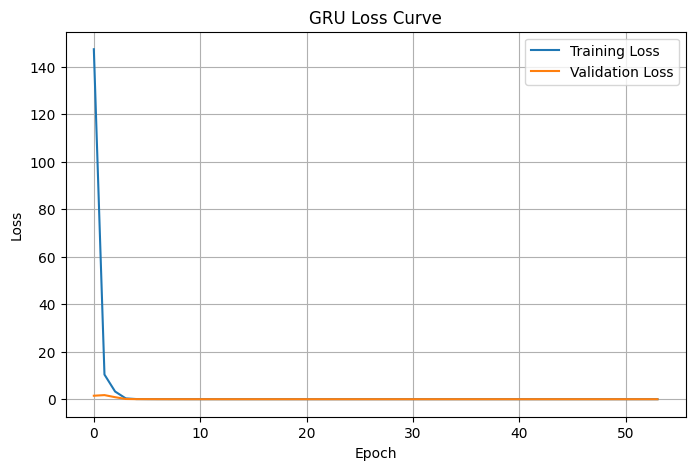

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(type(y_test))
print(y_test.shape)
print(y_pred.shape)

<class 'pandas.core.frame.DataFrame'>
(22209, 2)
(22209, 2)


In [ ]:
y_test = y_test.to_numpy().reshape(-1, 2)

In [ ]:
print(y_test.shape)
print(y_pred.shape)

(22209, 2)
(22209, 2)


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

print("R2 :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 : 0.9717553418905487
MAE : 0.05622237907415488
MSE : 0.0052521382879514595
RMSE : 0.07247163781750389


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_reshaped = X_train_scaled.reshape(
    X_train_scaled.shape[0], 1, X_train_scaled.shape[1]
)

X_test_reshaped = X_test_scaled.reshape(
    X_test_scaled.shape[0], 1, X_test_scaled.shape[1]
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
lstm = Sequential()

lstm.add(LSTM(128, return_sequences=True,
              input_shape=(X_train_reshaped.shape[1],
                           X_train_reshaped.shape[2])))

lstm.add(Dropout(0.2))

lstm.add(LSTM(64))

lstm.add(Dropout(0.2))

lstm.add(Dense(32, activation='relu'))

lstm.add(Dense(2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
X_train_reshaped = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_reshaped  = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

In [ ]:
optimizer = Adam(learning_rate=0.0005)

lstm.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=["mae"]
)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [ ]:
history = lstm.fit(
    X_train_reshaped,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - loss: 153.3805 - mae: 6.1246 - val_loss: 0.2487 - val_mae: 0.3956
Epoch 2/100
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 7.7101 - mae: 2.2136 - val_loss: 0.1368 - val_mae: 0.3211
Epoch 3/100
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 6.7332 - mae: 2.0695 - val_loss: 0.2813 - val_mae: 0.4988
Epoch 4/100
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 5.6131 - mae: 1.8864 - val_loss: 0.0424 - val_mae: 0.1431
Epoch 5/100
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 4.5269 - mae: 1.6930 - val_loss: 0.0526 - val_mae: 0.1750
Epoch 6/100
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 3.3644 - mae: 1.4599 - val_loss: 0.0348 - val_mae: 0.1259
Epoch 7/100
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 2.1473 - mae: 1.1644 - val_loss: 0.0663 - val_mae: 0.2256
Epoch 8/100
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 1.0903 - mae: 0.8255 - val_loss: 0.0546 - val_mae: 0.2016
Epoch 9/100
2221/2221 

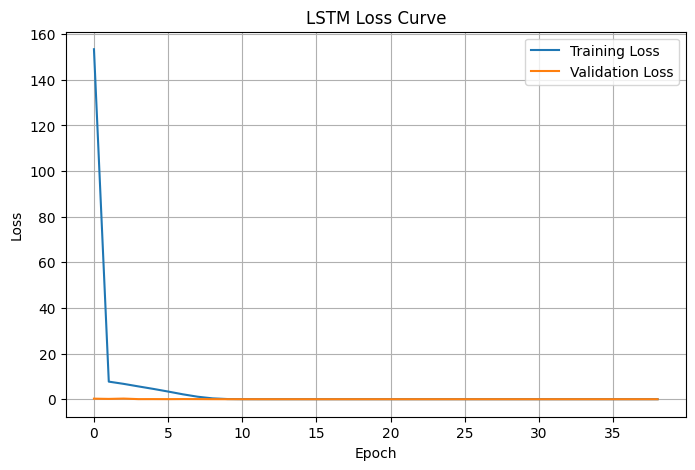

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Loss Curve")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
y_pred = lstm.predict(X_test_reshaped)

695/695 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


In [ ]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

print("R2 :", r2_score(y_test, y_pred))

print("MAE :", mean_absolute_error(y_test, y_pred))

mse = mean_squared_error(y_test, y_pred)

print("MSE :", mse)

print("RMSE :", np.sqrt(mse))

R2 : 0.9969751834869385
MAE : 0.016763290390372276
MSE : 0.000564226764254272
RMSE : 0.023753457943092665


In [ ]:
!pip install shap

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
feature_names = [
    "Rainfall",
    "MaxT",
    "MinT",
    "Wind",
    "Solar",
    "Humidity"
]

In [ ]:
background = X_train_scaled[:100]

In [ ]:
predict_fn = lambda x: lstm.predict(
    x.reshape(x.shape[0], 1, x.shape[1]),
    verbose=0
)

In [ ]:
explainer = shap.KernelExplainer(
    predict_fn,
    background
)

In [ ]:
sample = X_test_scaled[:50]

In [ ]:
shap_values = explainer.shap_values(sample)

  0%|          | 0/50 [00:00<?, ?it/s]

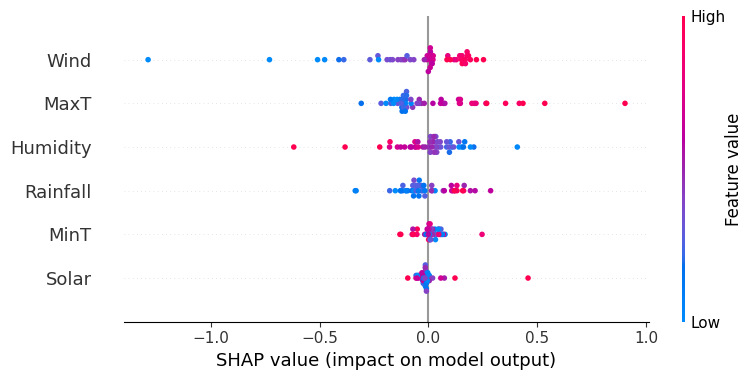

In [ ]:
shap.summary_plot(
    shap_values[:, :, 0],
    sample,
    feature_names=feature_names
)

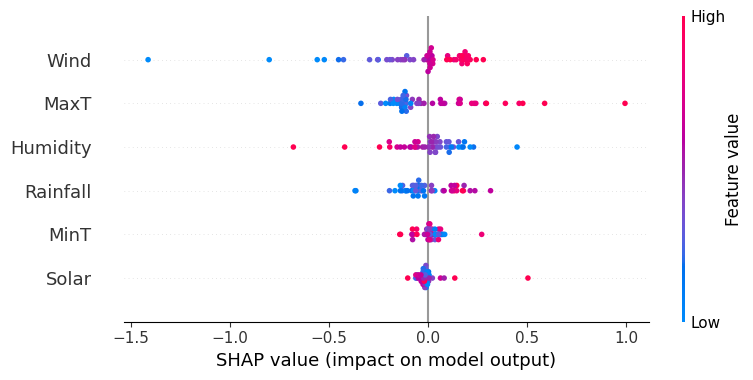

In [ ]:
shap.summary_plot(
    shap_values[:, :, 1],
    sample,
    feature_names=feature_names
)

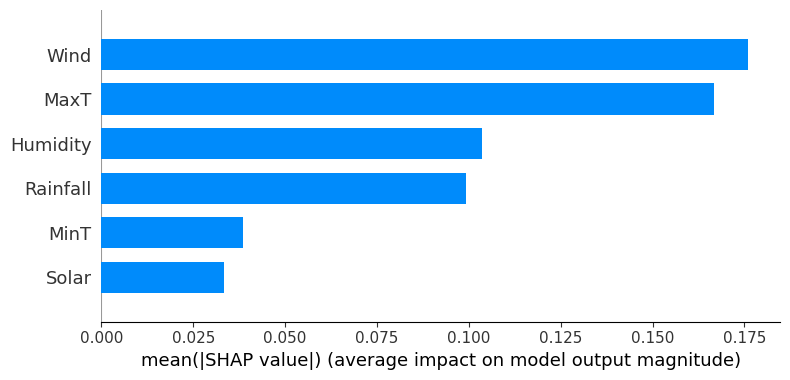

In [ ]:
shap.summary_plot(
    shap_values[:, :, 0],
    sample,
    feature_names=feature_names,
    plot_type="bar"
)

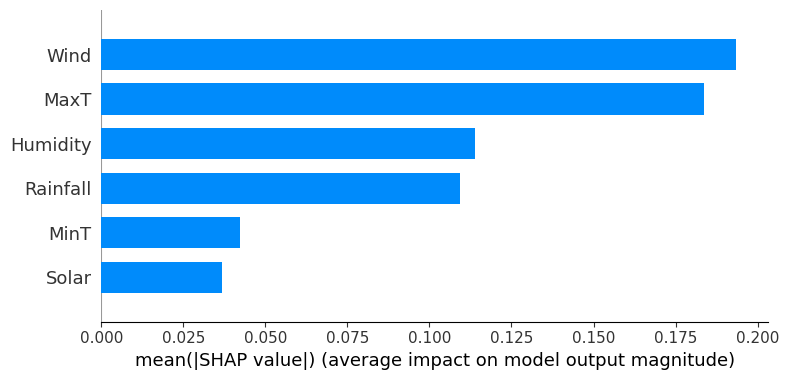

In [ ]:
shap.summary_plot(
    shap_values[:, :, 1],
    sample,
    feature_names=feature_names,
    plot_type="bar"
)

In [ ]:
print(X_test.columns)

Index(['Rainfall', 'MaxT', 'MinT', 'Wind', 'Solar', 'Humidity'], dtype='object')


In [ ]:
result = pd.DataFrame({
    'X': original_test['X'],
    'Y': original_test['Y'],
    'Predicted_ET': y_pred[:,0],
    'Predicted_PET': y_pred[:,1]
})

NameError: name 'original_test' is not defined

In [ ]:
import pandas as pd

result = pd.DataFrame({
    'X': X_test['X'],
    'Y': X_test['Y'],
    'Predicted_ET': y_pred[:,0],
    'Predicted_PET': y_pred[:,1]
})

result.to_csv("GIS_Output.csv", index=False)

KeyError: 'X'